# Alzheimer MRI Classification using ResNet50
Train / Validation split from train folder, augmentation, evaluation and prediction.

In [1]:
# ===============================
# 1 Import Libraries
# ===============================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import DenseNet121 # Changed to DenseNet
from tensorflow.keras.applications.densenet import preprocess_input # Changed preprocessing
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau # Added ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight # For dynamic class weights
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.10.0


In [2]:
# ===============================
# 2 GPU Configuration
# ===============================

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("GPUs:", gpus)


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ===============================
# 3 Paths and Parameters
# ===============================

TRAIN_DIR = "Alzheimer_Dataset/train"
TEST_DIR = "Alzheimer_Dataset/test"
VAL_DIR   = "Alzheimer_Dataset/val"

IMG_SIZE = (224,224)
BATCH_SIZE = 32
SEED = 42

CLASSES = [
'NonDemented',
'VeryMildDemented',
'MildDemented',
'ModerateDemented'
]


In [4]:
# ===============================
# 4 Load Train Dataset
# ===============================

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    seed=SEED,
    class_names=CLASSES, # Remember to keep this from our previous fix!
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


Found 4480 files belonging to 4 classes.


In [5]:
# ===============================
# 5 Validation Dataset
# ===============================

val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    seed=SEED,
    class_names=CLASSES,
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 960 files belonging to 4 classes.


In [6]:
# ===============================
# 6 Test Dataset
# ===============================

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    class_names=CLASSES,
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False # Crucial: Never shuffle the test set so your confusion matrix lines up
)

Found 960 files belonging to 4 classes.


In [7]:
# ===============================
# 7 Data Augmentation
# ===============================

data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1,0.1),
])

def augment(images, labels):
    images = data_augmentation(images)
    return images, labels

train_dataset = train_dataset.map(augment)


In [8]:
# ===============================
# 8 DenseNet Preprocessing
# ===============================

def preprocess(images, labels):
    images = preprocess_input(images)
    return images, labels

train_dataset = train_dataset.map(preprocess)
val_dataset = val_dataset.map(preprocess)
test_dataset = test_dataset.map(preprocess)


In [9]:
# ===============================
# 9 Prefetch for performance
# ===============================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)


In [10]:
# ===============================
# 10 Build DenseNet121 Model
# ===============================

base_model = DenseNet121(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

# Unfreeze the top layers for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-75]:  # Freeze everything except the last 30 layers
    layer.trainable = False

model = Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.4), # Reduced slightly for better learning
    layers.Dense(4, activation="softmax")
])

In [11]:
# ===============================
# 11 Compile Model
# ===============================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="acc"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 densenet121 (Functional)    (None, 7, 7, 1024)        7037504   
                                                                 
 global_average_pooling2d (G  (None, 1024)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 256)               262400    
                                                                 
 batch_normalization (BatchN  (None, 256)              1024      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 4)                

In [13]:
# ===============================
# 12 Training
# ===============================


# Dynamically compute class weights
y_train = np.concatenate([np.argmax(y.numpy(), axis=-1) for x, y in train_dataset])
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), weights))

# CRITICAL FIX: Cap the maximum weight so the model doesn't over-predict the rarest class
MAX_WEIGHT_CAP = 5.0 
class_weights = {k: min(v, MAX_WEIGHT_CAP) for k, v in class_weights.items()}

print(f"Capped Class Weights: {class_weights}")

# Callbacks
early_stop = EarlyStopping(
    monitor="val_acc",
    patience=10, 
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=5, 
    min_lr=1e-6
)

# Fit the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)


Capped Class Weights: {0: 0.49404499338332597, 1: 0.7249190938511327, 2: 1.792, 3: 5.0}
Epoch 1/100
140/140 [==============================] - 52s 284ms/step - loss: 1.3774 - acc: 0.3540 - auc: 0.6108 - val_loss: 1.0837 - val_acc: 0.5281 - val_auc: 0.7917 - lr: 1.0000e-04
Epoch 2/100
140/140 [==============================] - 39s 277ms/step - loss: 1.1248 - acc: 0.4464 - auc: 0.6871 - val_loss: 0.9927 - val_acc: 0.5771 - val_auc: 0.8244 - lr: 1.0000e-04
Epoch 3/100
140/140 [==============================] - 39s 278ms/step - loss: 1.0194 - acc: 0.4632 - auc: 0.7191 - val_loss: 0.9558 - val_acc: 0.5969 - val_auc: 0.8407 - lr: 1.0000e-04
Epoch 4/100
140/140 [==============================] - 39s 278ms/step - loss: 0.9085 - acc: 0.5145 - auc: 0.7668 - val_loss: 0.9335 - val_acc: 0.5969 - val_auc: 0.8516 - lr: 1.0000e-04
Epoch 5/100
140/140 [==============================] - 42s 299ms/step - loss: 0.8396 - acc: 0.5471 - auc: 0.7947 - val_loss: 0.8872 - val_acc: 0.6313 - val_auc: 0.8649 - lr

KeyboardInterrupt: 

NameError: name 'history' is not defined

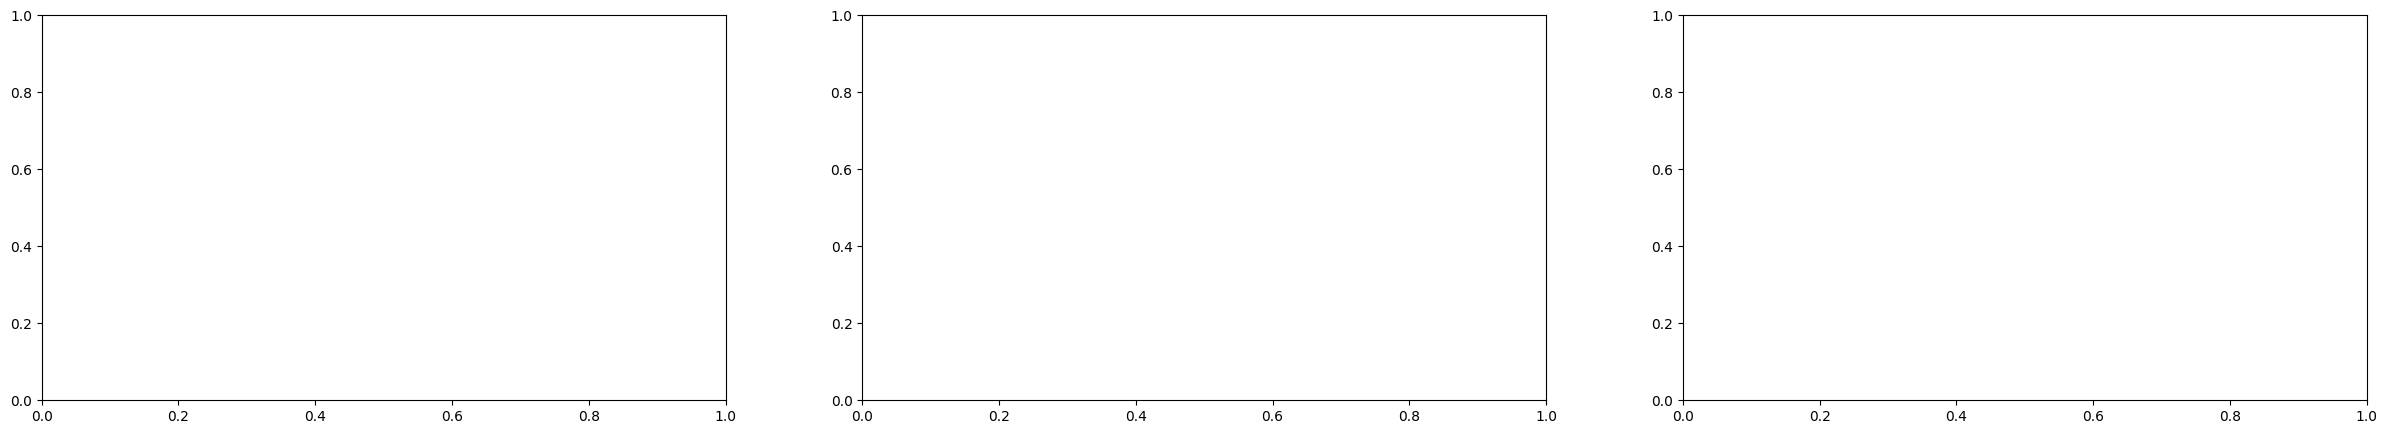

In [12]:
# ===============================
# 13 Plot Training Metrics
# ===============================

fig, ax = plt.subplots(1, 3, figsize = (30, 5))
ax = ax.ravel()

for i, metric in enumerate(["acc", "auc", "loss"]):
    ax[i].plot(history.history[metric])
    ax[i].plot(history.history["val_" + metric])
    ax[i].set_title("Model {}".format(metric))
    ax[i].set_xlabel("Epochs")
    ax[i].set_ylabel(metric)
    ax[i].legend(["train", "val"])

plt.show()


In [35]:
# ===============================
# 14 Evaluate on Test Set
# ===============================

test_scores = model.evaluate(test_dataset)

print('Testing Accuracy: %.2f%%' % (test_scores[1] * 100))


30/30 [==============================] - 5s 162ms/step - loss: 0.1508 - acc: 0.9510 - auc: 0.9942
Testing Accuracy: 95.10%


In [18]:
# ===============================
# 15 Predictions
# ===============================

y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images)
    y_true.extend(tf.argmax(labels, axis=1).numpy())
    y_pred.extend(tf.argmax(preds, axis=1).numpy())


1/1 [==============================] - 0s 29ms/step


In [19]:
# ===============================
# 16 Classification Report
# ===============================

print(classification_report(y_true, y_pred, target_names=CLASSES))


                  precision    recall  f1-score   support

     NonDemented       0.77      0.59      0.67       467
VeryMildDemented       0.54      0.62      0.58       358
    MildDemented       0.41      0.51      0.46       129
ModerateDemented       0.21      1.00      0.35         6

        accuracy                           0.59       960
       macro avg       0.48      0.68      0.51       960
    weighted avg       0.63      0.59      0.60       960



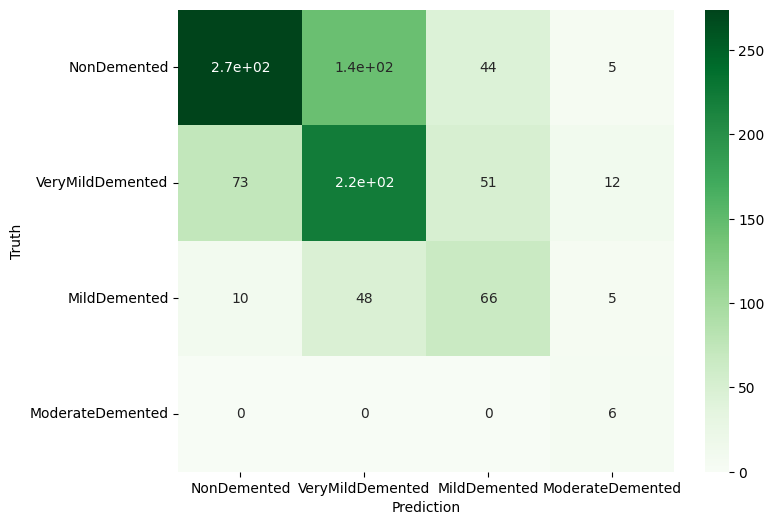

In [20]:
# ===============================
# 17 Confusion Matrix
# ===============================

conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    conf_matrix,
    annot=True,
    cmap="Greens",
    xticklabels=CLASSES,
    yticklabels=CLASSES
)

plt.xlabel("Prediction")
plt.ylabel("Truth")

plt.show()


In [ ]:
# ===============================
# 18 Save Model
# ===============================

model.save("alzheimer_densenet_model2.keras")
print("Model saved.")


Model saved.
